In [165]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1

In [166]:
alpha = 5
beta = 2
n = 10
k = 8
sigma = 0.2

a) Proposal Distribution

In [167]:
def propose_jump(pi, sigma, size = 1):
    result = scipy.stats.norm.rvs(
        loc = pi, # mean
        scale = sigma, # standard deviation
        size = size
    )
    return result if size > 1 else result.item()


def normalize(values: list):
    array = np.array(values, dtype = float)
    return (array - array.min()) / (array.max() - array.min())

b) Random walk

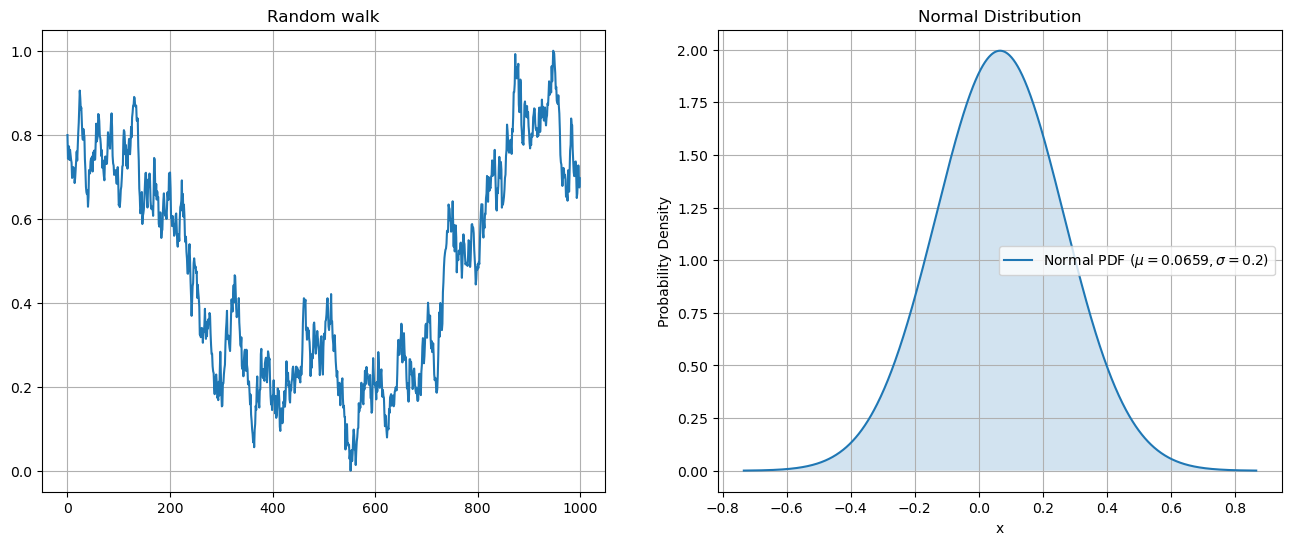

In [173]:
def plot_normal_distribution(ax, mean, sigma):
    # Generate x values around the mean
    x = np.linspace(mean - 4 * sigma, mean + 4 * sigma, 1000)

    # Compute the PDF
    y = scipy.stats.norm.pdf(x, loc = mean, scale = sigma)
    ax.plot(x, y, label=f'Normal PDF ($\mu={mean:.4f}, \sigma={sigma}$)')
    ax.fill_between(x, y, alpha=0.2)
    ax.set_title("Normal Distribution")
    ax.set_xlabel("x")
    ax.set_ylabel("Probability Density")
    ax.grid(True)
    ax.legend()

start = np.random.rand()

steps = []
for i in range(1000):
    pi = start
    if i > 0:
        pi = steps[i - 1]

    steps.append(propose_jump(pi, sigma))

walk = normalize(steps)

fig = plt.figure(figsize = (16, 6))

ax = fig.add_subplot(1, 2, 1)
ax.set_title('Random walk')
ax.grid(True)
ax.plot(walk)

ax = fig.add_subplot(1, 2, 2)
plot_normal_distribution(ax, start, sigma)


c) Jump decision

In [169]:
def acceptance_propability(pi, pi2, alpha, beta, n, k):
    numerator = scipy.stats.beta.pdf(x = pi2, a = alpha, b = beta) * scipy.stats.binom.pmf(k = k, n = n, p = pi2)
    denominator = scipy.stats.beta.pdf(x = pi, a = alpha, b = beta) * scipy.stats.binom.pmf(k = k, n = n, p = pi)
    return min(1, numerator / denominator)

def decide(pi, pi2, alpha, beta, n, k):
    if pi2 > 1 or pi2 < 0:
        return pi

    p = np.random.rand()
    acceptance_p = acceptance_propability(pi, pi2, alpha, beta, n, k)

    if p <= acceptance_p:
        return pi2
    else:
        return pi

d) Single-chain Metropolis algorithm

In [246]:
def metropolis_chain(n_steps, alpha, beta, n, k, sigma):
    chain = np.zeros(n_steps)
    pi = np.random.rand()

    for i in range(n_steps):
        pi2 = propose_jump(pi, sigma)
        pi = decide(pi, pi2, alpha, beta, n, k)
        chain[i] = pi

    return np.array(chain)


def plot_trace(pi, title: str = "Trace plot of π", ax: plt.Axes = None):
    ax = plt.subplots(figsize=(10, 4))[1] if ax is None else ax
    ax.plot(pi)
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_ylabel("π")
    ax.grid(True)


e) Verification: Hyperparameter tuning

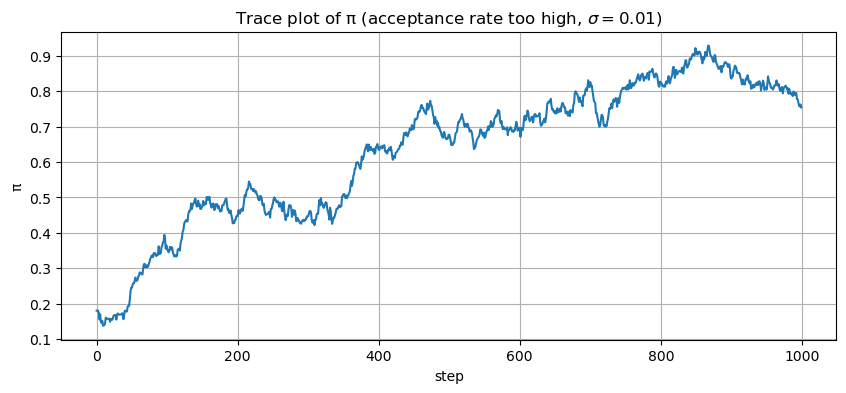

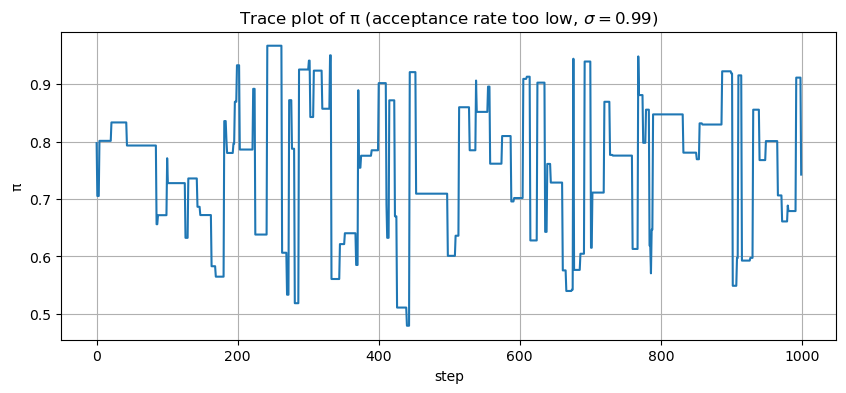

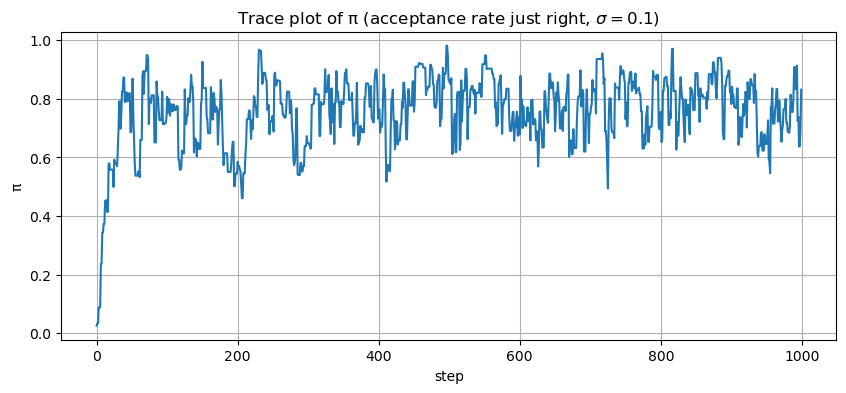

In [247]:
plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.01
    ),
    title = "Trace plot of π (acceptance rate too high, $\sigma = 0.01$)"
)

plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.99
    ),
    title = "Trace plot of π (acceptance rate too low, $\sigma = 0.99$)"
)

plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.1
    ),
    title = "Trace plot of π (acceptance rate just right, $\sigma = 0.1$)"
)


e) Verification: Visualize distribution

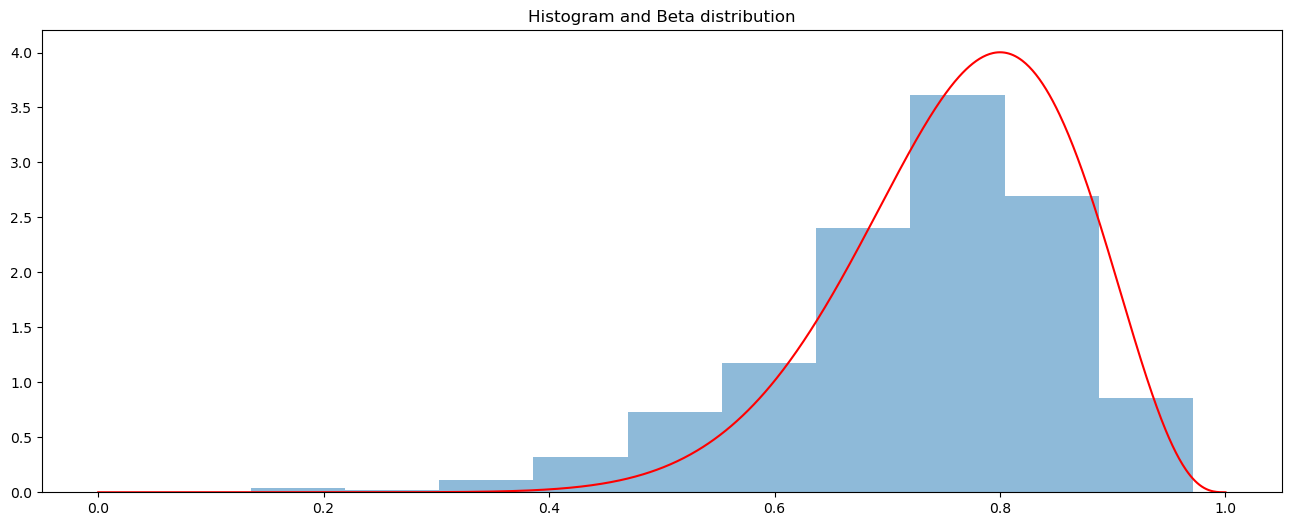

In [249]:
chain = metropolis_chain(
    n_steps = 1000,
    alpha = alpha,
    beta = beta,
    n = n,
    k = k,
    sigma = 0.1
)

def plot_hist_and_beta_distribution(chain, alpha, beta, n, k, title: str = "Histogram and Beta distribution", ax: plt.Axes = None):
    ax = plt.subplots(figsize=(16, 6))[1] if ax is None else ax
    ax.hist(chain, density = True, alpha = 0.5)

    beta_distribution_samples = np.linspace(0, 1, 1000)
    ax.plot(beta_distribution_samples, scipy.stats.beta.pdf(beta_distribution_samples, alpha + k, beta + n - k), color = 'red')
    ax.set_title(title)

plot_hist_and_beta_distribution(chain, alpha, beta, n, k)

f) Playing around

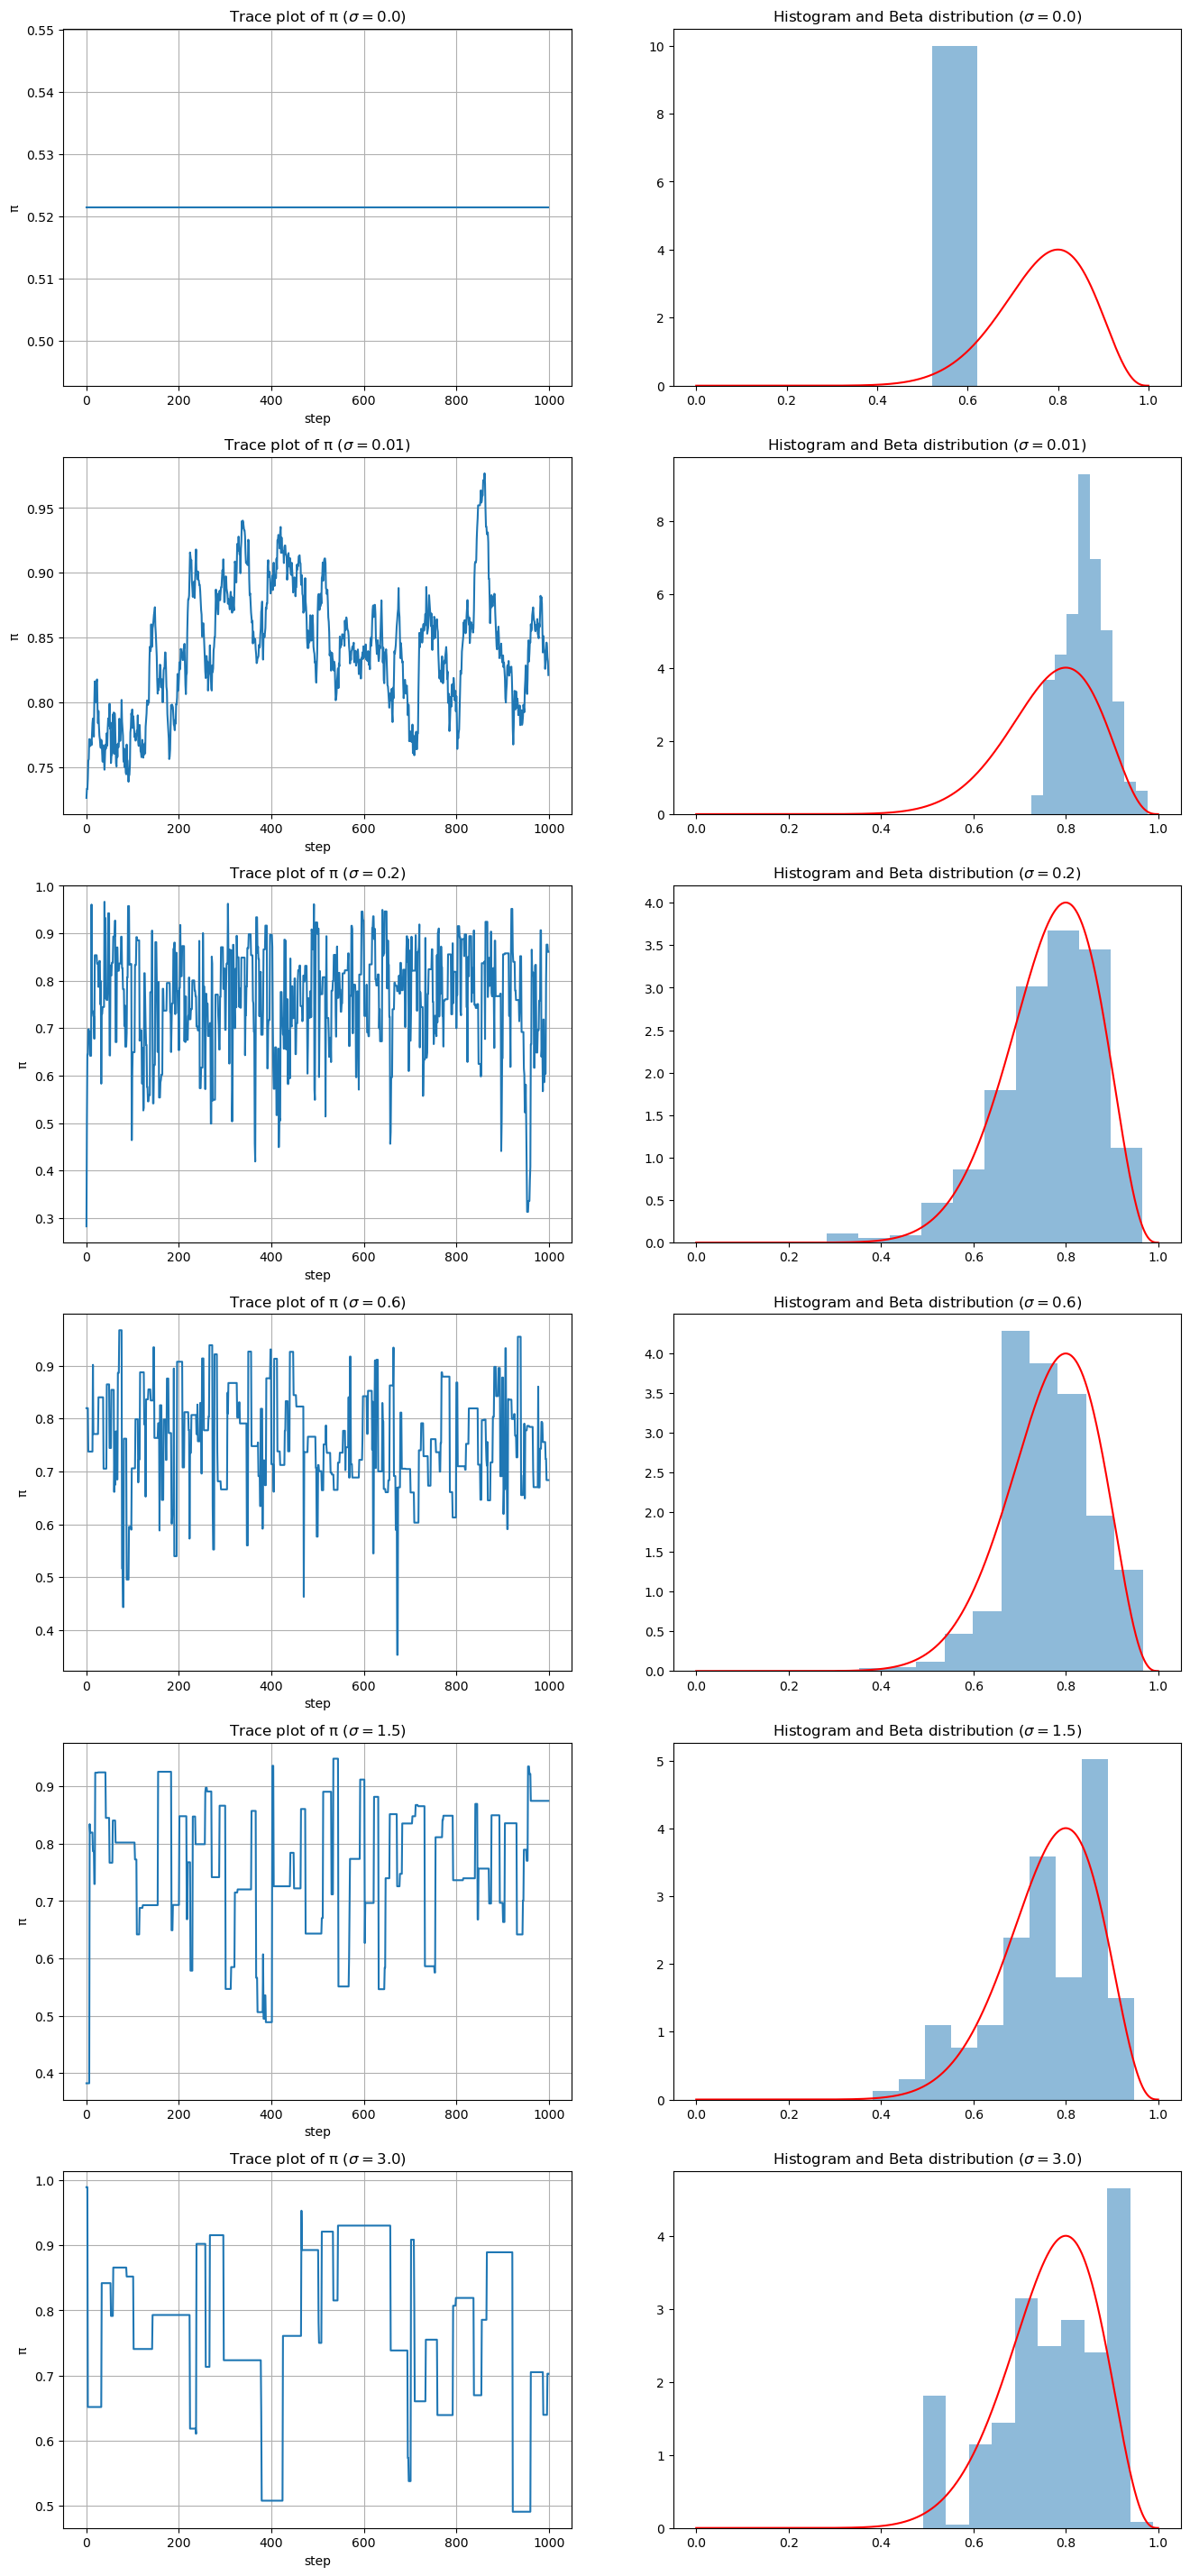

In [269]:
sigmas = [0.0, 0.01, 0.2, 0.6, 1.5, 3.0]

plot_nrows = len(sigmas)
fig = plt.figure(figsize = (16, 6 * plot_nrows))

for i, sigma in enumerate(sigmas):
    chain = metropolis_chain(
            n_steps = 1000,
            alpha = alpha,
            beta = beta,
            n = n,
            k = k,
            sigma = sigma
        )

    ax = fig.add_subplot(plot_nrows, 2, 2*i + 1)
    plot_trace(chain, title = f"Trace plot of π ($\sigma = {sigma}$)", ax = ax)

    ax = fig.add_subplot(plot_nrows, 2, 2*i + 2)
    plot_hist_and_beta_distribution(chain, alpha, beta, n, k, title = f"Histogram and Beta distribution ($\sigma = {sigma}$)", ax = ax)
